In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.utils import shuffle

In [4]:
features = pd.read_excel('镍基高温合金微观数据集合的副本.xlsx')
features

,Ni,Cr,Co,Fe,Al,Ti,Nb,Mo,W,C,B,Zr,基体相体积分数,强化相体积分数,液相温度,固相温度,凝固区间,强化相溶解温度,加工窗口
0,53.3950,17.74,0.31,18.579,0.53,0.97,5.48,2.97,0.00,0.026,0.0000,0.00,79.45,8.20,1360.00,1212.54,147.46,899.35,313.19
1,52.4000,19.01,0.02,18.837,0.57,1.00,5.07,3.06,0.00,0.030,0.0030,0.00,78.37,8.97,1358.19,1179.36,178.83,916.20,263.16
2,55.4315,18.93,11.00,0.000,1.57,3.13,0.00,9.83,0.00,0.075,0.0035,0.03,59.52,27.23,1331.25,1244.09,87.16,1056.06,188.03
3,53.2700,18.60,0.00,17.746,1.20,0.80,5.30,3.00,0.00,0.080,0.0040,0.00,75.00,13.59,1358.32,1197.36,160.96,938.05,259.31
4,51.6890,19.20,0.00,19.301,0.70,1.01,5.05,3.05,0.00,0.000,0.0000,0.00,75.06,10.48,1361.27,1204.02,157.25,932.34,271.68
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
130,74.0931,20.45,0.00,0.000,0.98,2.87,1.57,0.00,0.00,0.030,0.0069,0.00,79.64,17.81,1364.31,1271.07,93.24,948.97,322.10
131,60.4220,18.95,6.94,0.400,2.06,1.29,0.00,3.96,5.94,0.038,0.0000,0.00,77.93,19.17,1380.41,1337.77,42.64,968.71,369.06
132,60.6080,18.50,6.50,1.000,2.10,1.25,0.00,4.00,6.00,0.040,0.0020,0.00,77.82,19.12,1382.01,1322.39,59.62,965.59,356.80
133,62.6180,12.98,8.00,0.000,3.48,2.55,3.50,3.40,3.40,0.060,0.0120,0.00,45.19,51.88,1340.72,1268.37,72.35,1148.15,120.22


In [5]:
features = pd.read_excel('镍基高温合金微观数据集合的副本.xlsx')
label1 = np.array(features['基体相体积分数'])
label2 = np.array(features['强化相体积分数'])
label3 = np.array(features['液相温度'])
label4 = np.array(features['固相温度'])
label5 = np.array(features['凝固区间'])
label6 = np.array(features['强化相溶解温度'])
label7 = np.array(features['加工窗口'])
features= features.drop('基体相体积分数', axis = 1)
features= features.drop('强化相体积分数', axis = 1)
features= features.drop('液相温度', axis = 1)
features= features.drop('固相温度', axis = 1)
features= features.drop('凝固区间', axis = 1)
features= features.drop('强化相溶解温度', axis = 1)
features= features.drop('加工窗口', axis = 1)
features

,Ni,Cr,Co,Fe,Al,Ti,Nb,Mo,W,C,B,Zr
0,53.3950,17.74,0.31,18.579,0.53,0.97,5.48,2.97,0.00,0.026,0.0000,0.00
1,52.4000,19.01,0.02,18.837,0.57,1.00,5.07,3.06,0.00,0.030,0.0030,0.00
2,55.4315,18.93,11.00,0.000,1.57,3.13,0.00,9.83,0.00,0.075,0.0035,0.03
3,53.2700,18.60,0.00,17.746,1.20,0.80,5.30,3.00,0.00,0.080,0.0040,0.00
4,51.6890,19.20,0.00,19.301,0.70,1.01,5.05,3.05,0.00,0.000,0.0000,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...
130,74.0931,20.45,0.00,0.000,0.98,2.87,1.57,0.00,0.00,0.030,0.0069,0.00
131,60.4220,18.95,6.94,0.400,2.06,1.29,0.00,3.96,5.94,0.038,0.0000,0.00
132,60.6080,18.50,6.50,1.000,2.10,1.25,0.00,4.00,6.00,0.040,0.0020,0.00
133,62.6180,12.98,8.00,0.000,3.48,2.55,3.50,3.40,3.40,0.060,0.0120,0.00


In [6]:
n_samples, n_features = features.shape
features = pd.get_dummies(features)
feature_list = list(features.columns)#获取列名
features = np.array(features)#获取影响因子

In [7]:
from sklearn.model_selection import train_test_split
test_ratio = 0.25#按照五比一划分数据集合；4/5的数据用于训练集合，1/5的数据用于验证集合。
SEED = 26 ### the test/train data is checked on this seed, it has similiar distribution to the whole dataset
train_features1, test_features1, train_labels1, test_labels1 = train_test_split(features, label1,
                                                                            test_size = test_ratio,
                                                                            random_state = SEED)
train_features2, test_features2, train_labels2, test_labels2 = train_test_split(features, label2,
                                                                            test_size = test_ratio,
                                                                            random_state = SEED)
train_features3, test_features3, train_labels3, test_labels3 = train_test_split(features, label3,
                                                                            test_size = test_ratio,
                                                                            random_state = SEED)
train_features4, test_features4, train_labels4, test_labels4 = train_test_split(features, label4,
                                                                            test_size = test_ratio,
                                                                            random_state = SEED)
train_features5, test_features5, train_labels5, test_labels5 = train_test_split(features, label5,
                                                                            test_size = test_ratio,
                                                                            random_state = SEED)
train_features6, test_features6, train_labels6, test_labels6 = train_test_split(features, label6,
                                                                            test_size = test_ratio,
                                                                            random_state = SEED)
train_features7, test_features7, train_labels7, test_labels7 = train_test_split(features, label7,
                                                                            test_size = test_ratio,
                                                                            random_state = SEED)

In [8]:
model_seed = 100 
from sklearn.ensemble import RandomForestRegressor
Model1 = RandomForestRegressor(random_state=model_seed)
Model2 = RandomForestRegressor(random_state=model_seed)
Model3 = RandomForestRegressor(random_state=model_seed)
Model4 = RandomForestRegressor(random_state=model_seed)
Model5 = RandomForestRegressor(random_state=model_seed)
Model6 = RandomForestRegressor(random_state=model_seed)
Model7 = RandomForestRegressor(random_state=model_seed)

In [9]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
def evaluate(true_labels, pred_labels):
    errors = abs(pred_labels - true_labels)
    MAE = mean_absolute_error(true_labels, pred_labels)
    mape = 100 * np.mean(errors / true_labels)
    r2 = r2_score(true_labels, pred_labels)
    RMSE = mean_squared_error(true_labels, pred_labels,squared=False)
    return mape, MAE, RMSE, r2

In [10]:
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import LeaveOneOut
from numpy import absolute
from numpy import mean
from numpy import std
from sklearn.model_selection import cross_validate
from sklearn.metrics import mean_squared_error
cv = LeaveOneOut()
Model1.fit(train_features1,train_labels1)
Model2.fit(train_features2,train_labels2)
Model3.fit(train_features3,train_labels3)
Model4.fit(train_features4,train_labels4)
Model5.fit(train_features5,train_labels5)
Model6.fit(train_features6,train_labels6)
Model7.fit(train_features7,train_labels7)


from sklearn.model_selection import cross_val_predict
y_pred1 = cross_val_predict(Model1, features, label1, cv=cv)
y_pred2 = cross_val_predict(Model2, features, label2, cv=cv)
y_pred3 = cross_val_predict(Model3, features, label3, cv=cv)
y_pred4 = cross_val_predict(Model4, features, label4, cv=cv)
y_pred5 = cross_val_predict(Model5, features, label5, cv=cv)
y_pred6 = cross_val_predict(Model6, features, label6, cv=cv)
y_pred7 = cross_val_predict(Model7, features, label7, cv=cv)

model_accuracy1, model_MAE1, model_RMSE1, model_r21 = evaluate(label1, y_pred1)
model_accuracy2, model_MAE2, model_RMSE2, model_r22 = evaluate(label2, y_pred2)
model_accuracy3, model_MAE3, model_RMSE3, model_r23 = evaluate(label3, y_pred3)
model_accuracy4, model_MAE4, model_RMSE4, model_r24 = evaluate(label4, y_pred4)
model_accuracy5, model_MAE5, model_RMSE5, model_r25 = evaluate(label5, y_pred5)
model_accuracy6, model_MAE6, model_RMSE6, model_r26 = evaluate(label6, y_pred6)
model_accuracy7, model_MAE7, model_RMSE7, model_r27 = evaluate(label7, y_pred7)


final_output = pd.DataFrame()
final_output.loc[:,1] = [model_accuracy1, model_MAE1, model_RMSE1, model_r21]
final_output.loc[:,2] = [model_accuracy2, model_MAE2, model_RMSE2, model_r22]
final_output.loc[:,3] = [model_accuracy3, model_MAE3, model_RMSE3, model_r23]
final_output.loc[:,4] = [model_accuracy4, model_MAE4, model_RMSE4, model_r24]
final_output.loc[:,5] = [model_accuracy5, model_MAE5, model_RMSE5, model_r25]
final_output.loc[:,6] = [model_accuracy6, model_MAE6, model_RMSE6, model_r26]
final_output.loc[:,7] = [model_accuracy7, model_MAE7, model_RMSE7, model_r27]



final_output=pd.DataFrame(final_output)
final_output=final_output.T
final_output.columns = ['MAPE', 'MAE', 'RMSE', 'R2']
final_output.index = [ '基体相体积分数','强化相体积分数', ' 液相温度','固相温度',
                      '凝固区间','强化相溶解温度','加工窗口']
final_output.to_excel(r'final_output_LOOCV1.xlsx', index = True)

In [12]:
import matplotlib.pyplot as plt
predictions1 = y_pred1
predictions2 = y_pred2
predictions3 = y_pred3
predictions4 = y_pred4
predictions5 = y_pred5
predictions6 = y_pred6
predictions7 = y_pred7
test_labels1 = label1
test_labels2 = label2
test_labels3 = label3
test_labels4 = label4
test_labels5 = label5
test_labels6 = label6
test_labels7 = label7

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


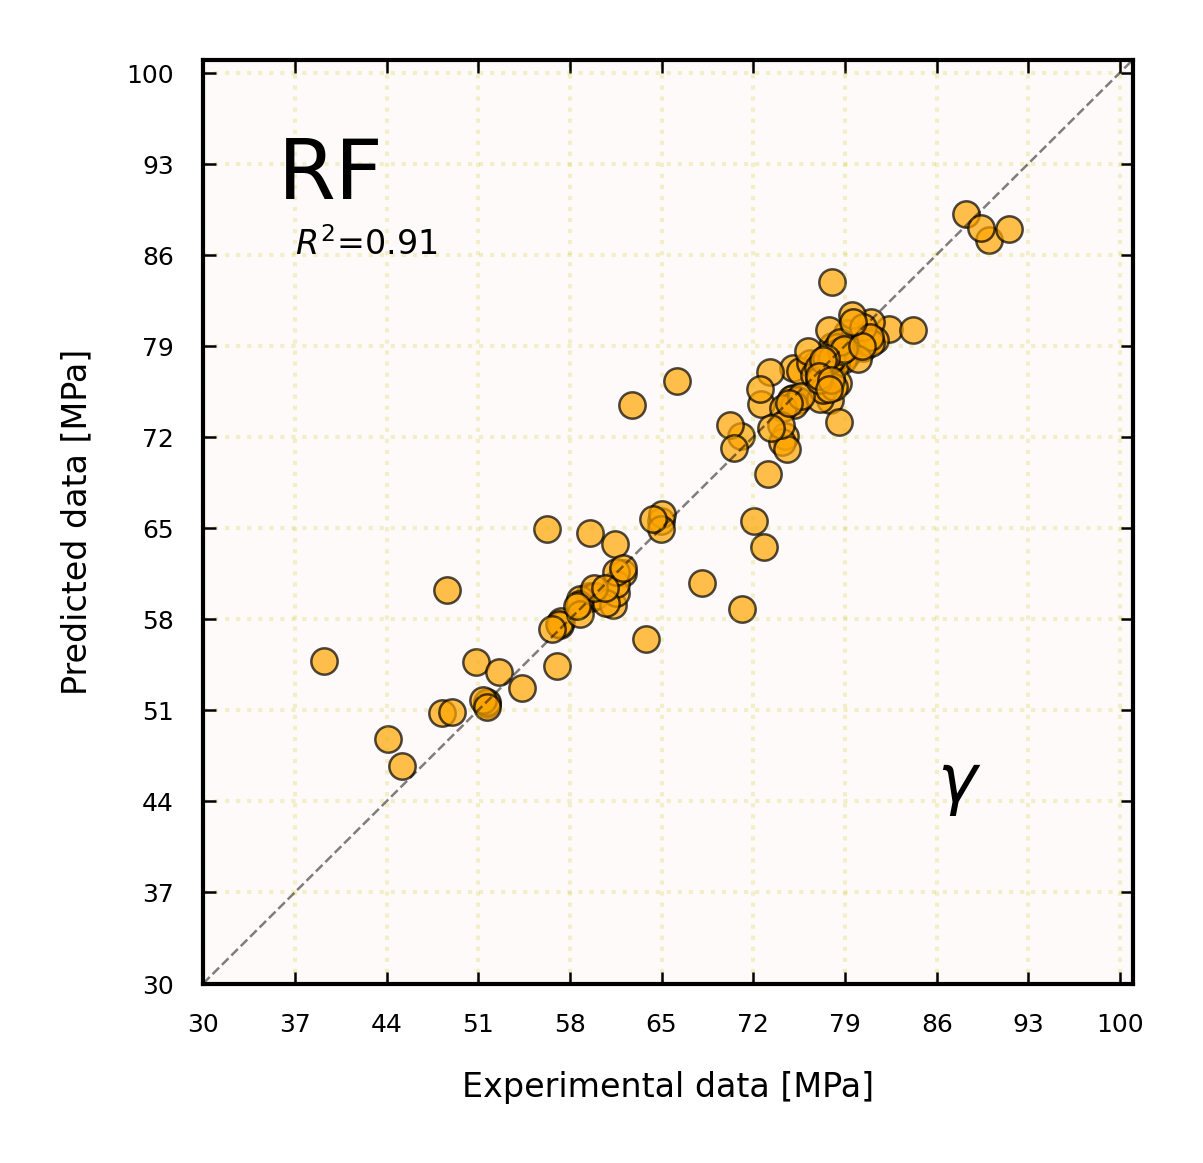

In [20]:
plt.rcParams['figure.figsize']=(2.0,2.0)
plt.rcParams['savefig.dpi'] = 600 #图片像素
plt.rcParams['figure.dpi'] = 600 #分辨率
ax = plt.axes()
ax.set_facecolor("snow")
ax.set(facecolor = "snow")#背景颜色设置
plt.grid()
plt.tick_params(grid_color='y',grid_alpha=0.2,
                        grid_linewidth=0.5,grid_linestyle=':')#网格背景划分
ax.spines['bottom'].set_linewidth('0.5')#设置边框线宽为2.0
ax.spines['bottom'].set_linestyle("-")
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_linewidth('0.5')#设置边框线宽为2.0
ax.spines['left'].set_linestyle("-")
ax.spines['left'].set_color('black')
ax.spines['top'].set_linewidth('0.5')#设置边框线宽为2.0
ax.spines['top'].set_linestyle("-")
ax.spines['top'].set_color('black')
ax.spines['right'].set_linewidth('0.5')#设置边框线宽为2.0
ax.spines['right'].set_linestyle("-")
ax.spines['right'].set_color('black')
#设置图框线粗细
new_ticks = list(np.arange(30,101,7))
plt.xticks(new_ticks,size=3)
plt.yticks(new_ticks,size=3)
plt.tick_params( which='major', direction='in', length=1.5,width=0.3, color='red', top=True,right=True)#设置边框刻度
plt.legend(title='SVR',frameon=False)
plt.text(37, 86,'$R^2$=0.91',fontsize=4)# 在图中添加文字
plt.text(86, 44,'$γ$',fontsize=8)# 在图中添加文字
plt.plot([30,101],[30,101],'k--',linewidth = '0.3',alpha=0.5)
plt.scatter(test_labels1,predictions1,alpha=0.7,s=10,linewidths=0.3, c='orange',edgecolor='#000000')
plt.tick_params(axis='x',colors='black')
plt.tick_params(axis='y',colors='black')
plt.xlabel('Experimental data [MPa]',size=4)
plt.ylabel('Predicted data [MPa]',size=4)
plt.margins(x=0)
plt.margins(y=0)
plt.savefig('./1png')

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


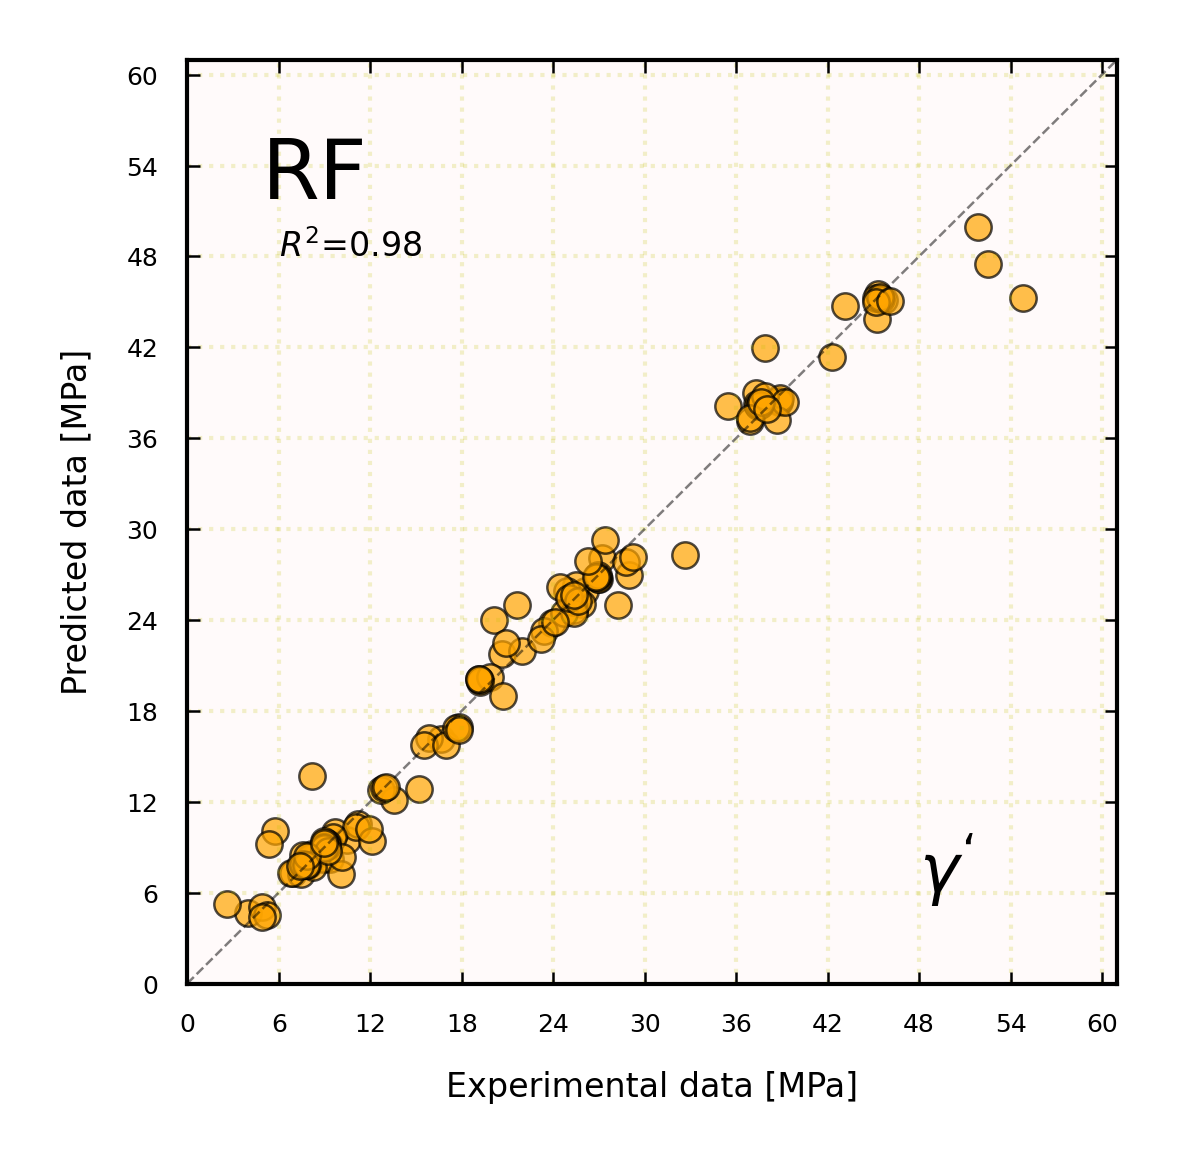

In [21]:
plt.rcParams['figure.figsize']=(2.0,2.0)
plt.rcParams['savefig.dpi'] = 600 #图片像素
plt.rcParams['figure.dpi'] = 600 #分辨率
ax = plt.axes()
ax.set_facecolor("snow")
ax.set(facecolor = "snow")#背景颜色设置
plt.grid()
plt.tick_params(grid_color='y',grid_alpha=0.2,
                        grid_linewidth=0.5,grid_linestyle=':')#网格背景划分
ax.spines['bottom'].set_linewidth('0.5')#设置边框线宽为2.0
ax.spines['bottom'].set_linestyle("-")
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_linewidth('0.5')#设置边框线宽为2.0
ax.spines['left'].set_linestyle("-")
ax.spines['left'].set_color('black')
ax.spines['top'].set_linewidth('0.5')#设置边框线宽为2.0
ax.spines['top'].set_linestyle("-")
ax.spines['top'].set_color('black')
ax.spines['right'].set_linewidth('0.5')#设置边框线宽为2.0
ax.spines['right'].set_linestyle("-")
ax.spines['right'].set_color('black')
#设置图框线粗细
new_ticks = list(np.arange(0,61,6))
plt.xticks(new_ticks,size=3)
plt.yticks(new_ticks,size=3)
plt.tick_params( which='major', direction='in', length=1.5,width=0.3, color='red', top=True,right=True)#设置边框刻度
plt.legend(title='RF',frameon=False)
plt.text(6, 48,'$R^2$=0.98',fontsize=4)# 在图中添加文字
plt.text(48, 6,'$γ^‘$',fontsize=8)# 在图中添加文字
plt.plot([0,61],[0,61],'k--',linewidth = '0.3',alpha=0.5)
plt.scatter(test_labels2,predictions2,alpha=0.7,s=10,linewidths=0.3, c='orange',edgecolor='#000000')
plt.tick_params(axis='x',colors='black')
plt.tick_params(axis='y',colors='black')
plt.xlabel('Experimental data [MPa]',size=4)
plt.ylabel('Predicted data [MPa]',size=4)
plt.margins(x=0)
plt.margins(y=0)
plt.savefig('./2png')

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


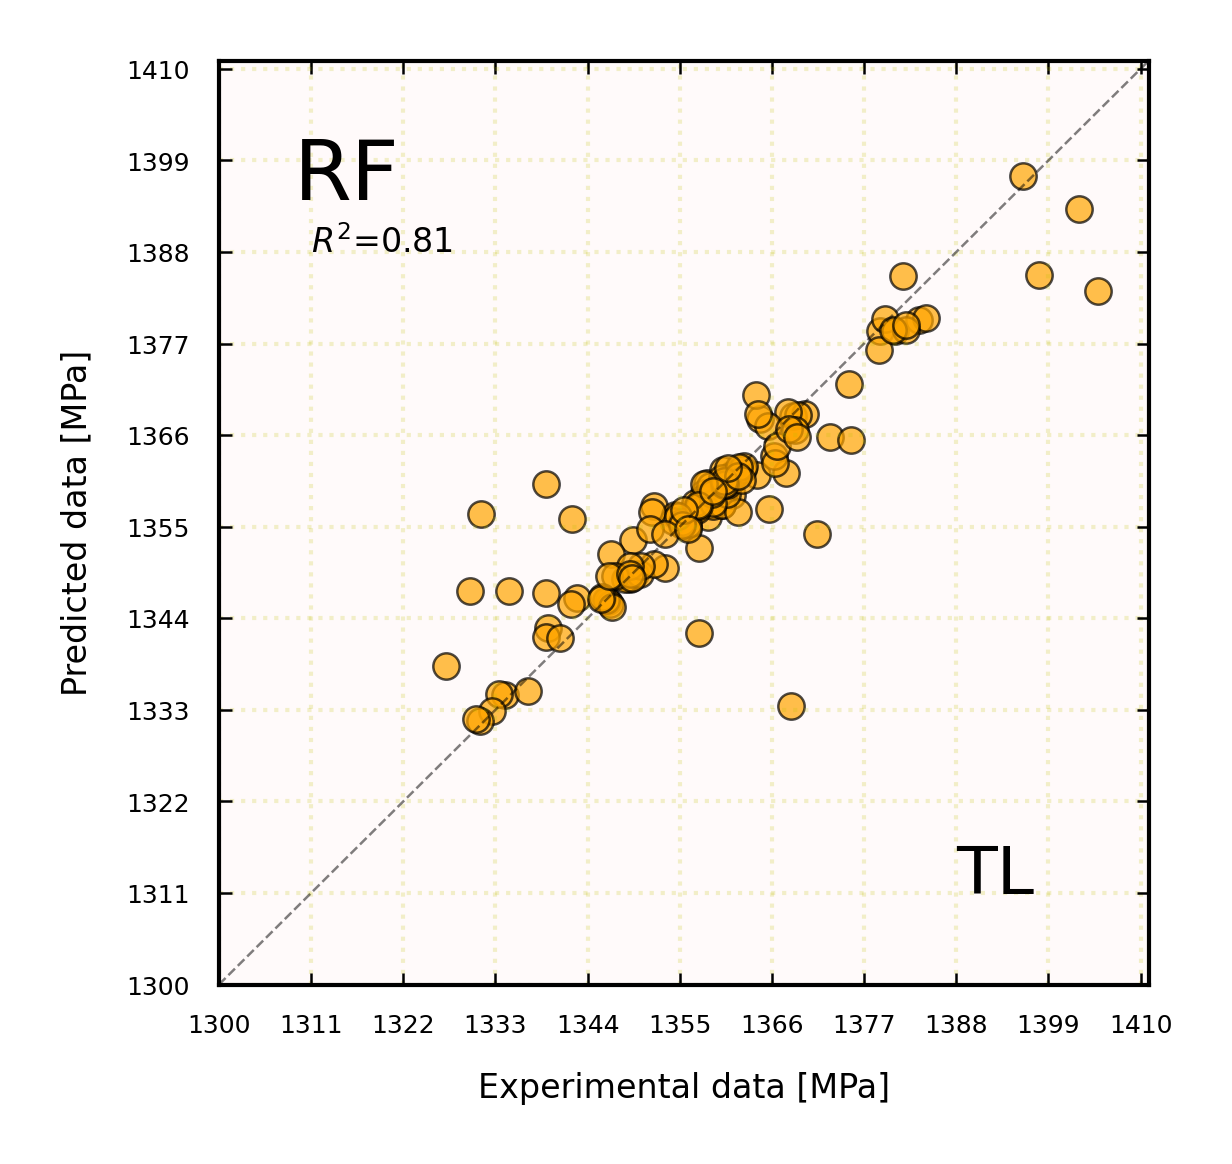

In [28]:
plt.rcParams['figure.figsize']=(2.0,2.0)
plt.rcParams['savefig.dpi'] = 600 #图片像素
plt.rcParams['figure.dpi'] = 600 #分辨率
ax = plt.axes()
ax.set_facecolor("snow")
ax.set(facecolor = "snow")#背景颜色设置
plt.grid()
plt.tick_params(grid_color='y',grid_alpha=0.2,
                        grid_linewidth=0.5,grid_linestyle=':')#网格背景划分
ax.spines['bottom'].set_linewidth('0.5')#设置边框线宽为2.0
ax.spines['bottom'].set_linestyle("-")
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_linewidth('0.5')#设置边框线宽为2.0
ax.spines['left'].set_linestyle("-")
ax.spines['left'].set_color('black')
ax.spines['top'].set_linewidth('0.5')#设置边框线宽为2.0
ax.spines['top'].set_linestyle("-")
ax.spines['top'].set_color('black')
ax.spines['right'].set_linewidth('0.5')#设置边框线宽为2.0
ax.spines['right'].set_linestyle("-")
ax.spines['right'].set_color('black')
#设置图框线粗细
new_ticks = list(np.arange(1300,1411,11))
plt.xticks(new_ticks,size=3)
plt.yticks(new_ticks,size=3)
plt.tick_params( which='major', direction='in', length=1.5,width=0.3, color='red', top=True,right=True)#设置边框刻度
plt.legend(title='RF',frameon=False)
plt.text(1311, 1388,'$R^2$=0.81',fontsize=4)# 在图中添加文字
plt.text(1388, 1311,'TL',fontsize=8)# 在图中添加文字
plt.plot([1300,1411],[1300,1411],'k--',linewidth = '0.3',alpha=0.5)
plt.scatter(test_labels3,predictions3,alpha=0.7,s=10,linewidths=0.3, c='orange',edgecolor='#000000')
plt.tick_params(axis='x',colors='black')
plt.tick_params(axis='y',colors='black')
plt.xlabel('Experimental data [MPa]',size=4)
plt.ylabel('Predicted data [MPa]',size=4)
plt.margins(x=0)
plt.margins(y=0)
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


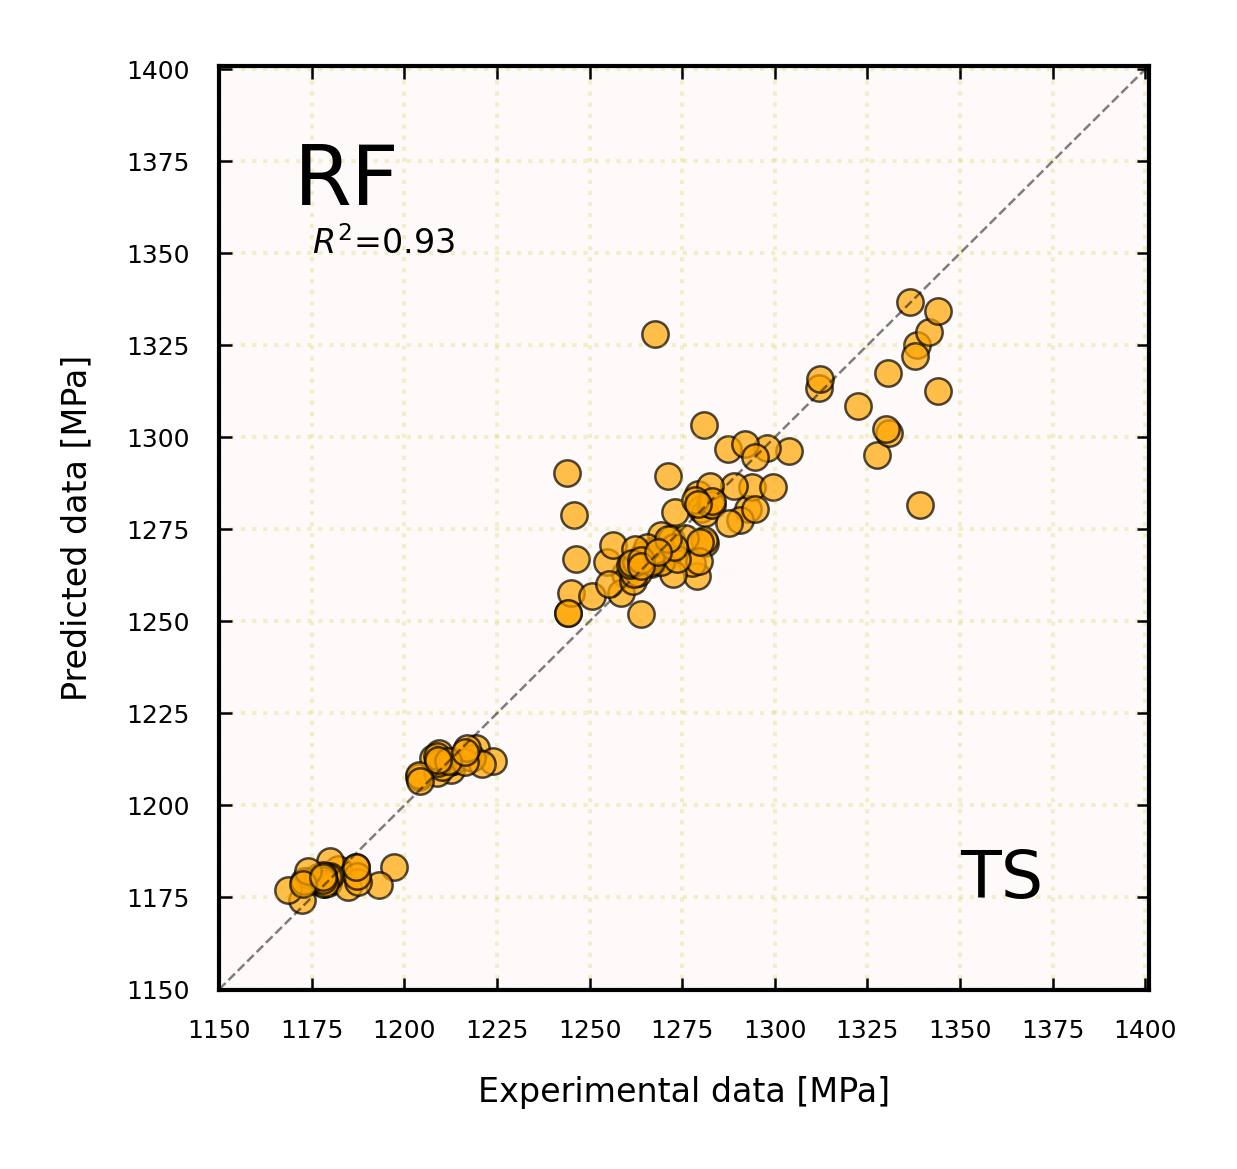

In [33]:
plt.rcParams['figure.figsize']=(2.0,2.0)
plt.rcParams['savefig.dpi'] = 600 #图片像素
plt.rcParams['figure.dpi'] = 600 #分辨率
ax = plt.axes()
ax.set_facecolor("snow")
ax.set(facecolor = "snow")#背景颜色设置
plt.grid()
plt.tick_params(grid_color='y',grid_alpha=0.2,
                        grid_linewidth=0.5,grid_linestyle=':')#网格背景划分
ax.spines['bottom'].set_linewidth('0.5')#设置边框线宽为2.0
ax.spines['bottom'].set_linestyle("-")
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_linewidth('0.5')#设置边框线宽为2.0
ax.spines['left'].set_linestyle("-")
ax.spines['left'].set_color('black')
ax.spines['top'].set_linewidth('0.5')#设置边框线宽为2.0
ax.spines['top'].set_linestyle("-")
ax.spines['top'].set_color('black')
ax.spines['right'].set_linewidth('0.5')#设置边框线宽为2.0
ax.spines['right'].set_linestyle("-")
ax.spines['right'].set_color('black')
#设置图框线粗细
new_ticks = list(np.arange(1150,1401,25))
plt.xticks(new_ticks,size=3)
plt.yticks(new_ticks,size=3)
plt.tick_params( which='major', direction='in', length=1.5,width=0.3, color='red', top=True,right=True)#设置边框刻度
plt.legend(title='RF',frameon=False)
plt.text(1175, 1350,'$R^2$=0.93',fontsize=4)# 在图中添加文字
plt.text(1350, 1175,'TS',fontsize=8)# 在图中添加文字
plt.plot([1150,1401],[1150,1401],'k--',linewidth = '0.3',alpha=0.5)
plt.scatter(test_labels4,predictions4,alpha=0.7,s=10,linewidths=0.3, c='orange',edgecolor='#000000')
plt.tick_params(axis='x',colors='black')
plt.tick_params(axis='y',colors='black')
plt.xlabel('Experimental data [MPa]',size=4)
plt.ylabel('Predicted data [MPa]',size=4)
plt.margins(x=0)
plt.margins(y=0)
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


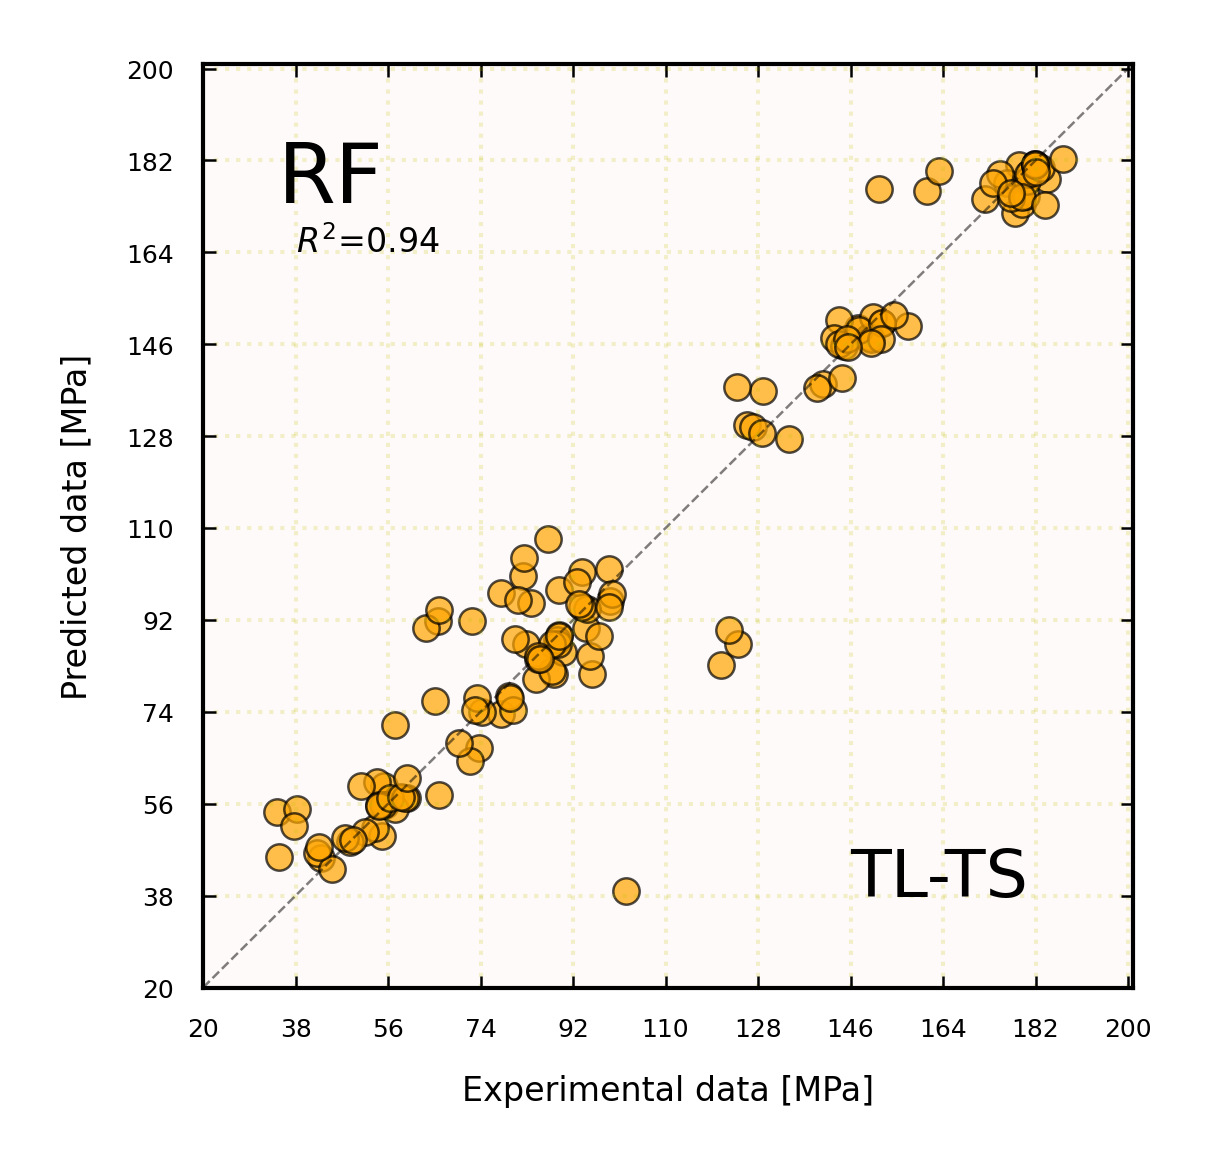

In [36]:
plt.rcParams['figure.figsize']=(2.0,2.0)
plt.rcParams['savefig.dpi'] = 600 #图片像素
plt.rcParams['figure.dpi'] = 600 #分辨率
ax = plt.axes()
ax.set_facecolor("snow")
ax.set(facecolor = "snow")#背景颜色设置
plt.grid()
plt.tick_params(grid_color='y',grid_alpha=0.2,
                        grid_linewidth=0.5,grid_linestyle=':')#网格背景划分
ax.spines['bottom'].set_linewidth('0.5')#设置边框线宽为2.0
ax.spines['bottom'].set_linestyle("-")
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_linewidth('0.5')#设置边框线宽为2.0
ax.spines['left'].set_linestyle("-")
ax.spines['left'].set_color('black')
ax.spines['top'].set_linewidth('0.5')#设置边框线宽为2.0
ax.spines['top'].set_linestyle("-")
ax.spines['top'].set_color('black')
ax.spines['right'].set_linewidth('0.5')#设置边框线宽为2.0
ax.spines['right'].set_linestyle("-")
ax.spines['right'].set_color('black')
#设置图框线粗细
new_ticks = list(np.arange(20,201,18))
plt.xticks(new_ticks,size=3)
plt.yticks(new_ticks,size=3)
plt.tick_params( which='major', direction='in', length=1.5,width=0.3, color='red', top=True,right=True)#设置边框刻度
plt.legend(title='RF',frameon=False)
plt.text(38, 164,'$R^2$=0.94',fontsize=4)# 在图中添加文字
plt.text(146, 38,'TL-TS',fontsize=8)# 在图中添加文字
plt.plot([20,201],[20,201],'k--',linewidth = '0.3',alpha=0.5)
plt.scatter(test_labels5,predictions5,alpha=0.7,s=10,linewidths=0.3, c='orange',edgecolor='#000000')
plt.tick_params(axis='x',colors='black')
plt.tick_params(axis='y',colors='black')
plt.xlabel('Experimental data [MPa]',size=4)
plt.ylabel('Predicted data [MPa]',size=4)
plt.margins(x=0)
plt.margins(y=0)
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


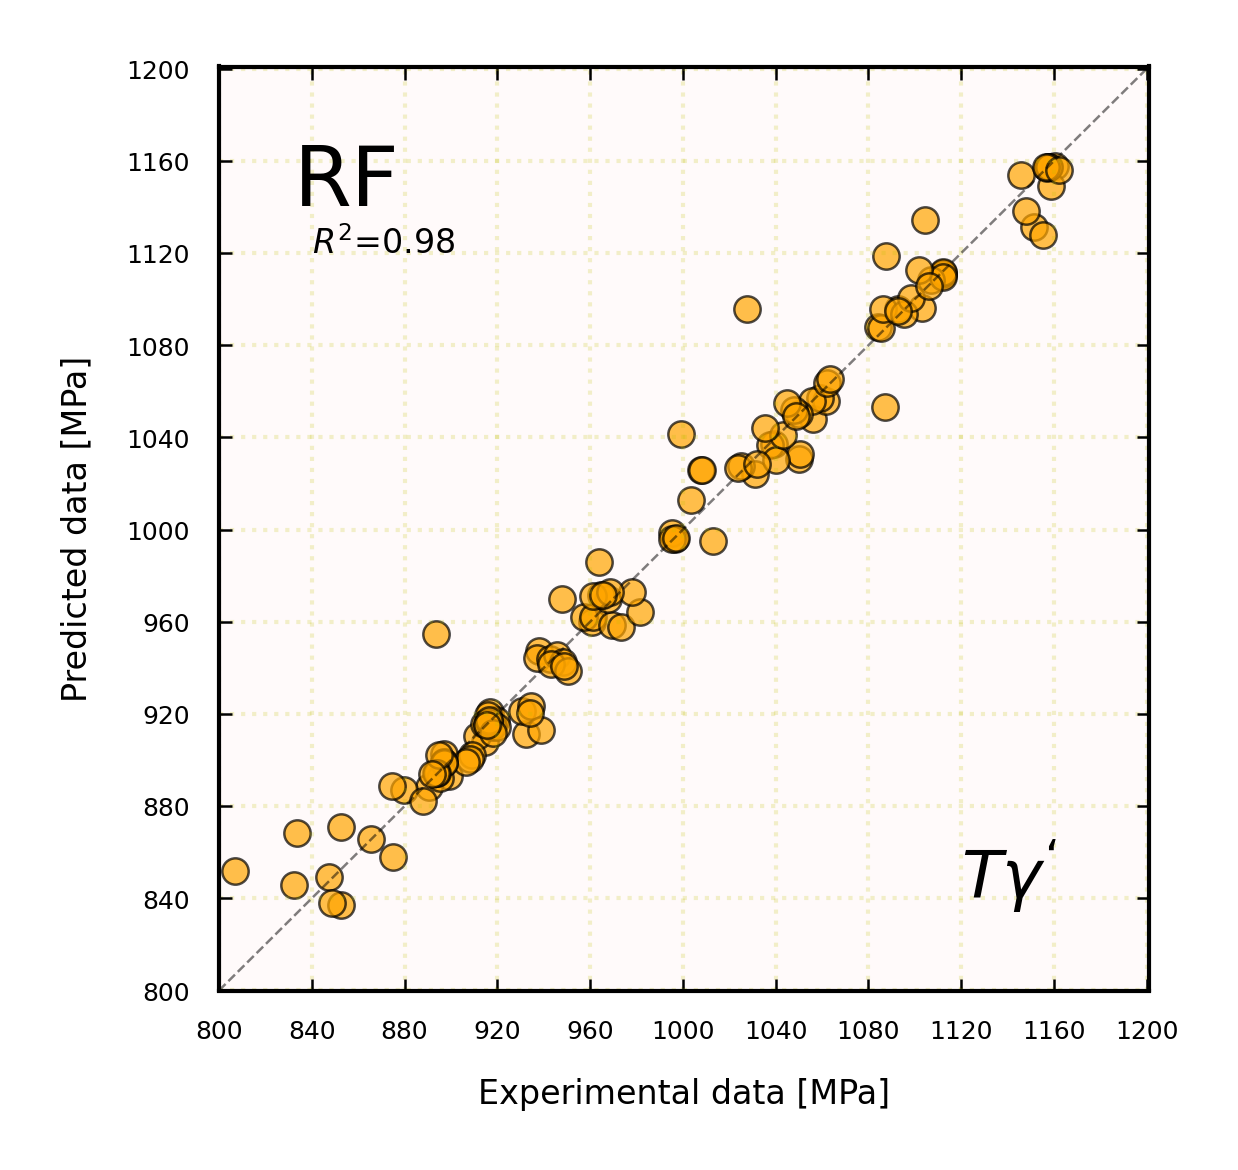

In [37]:
plt.rcParams['figure.figsize']=(2.0,2.0)
plt.rcParams['savefig.dpi'] = 600 #图片像素
plt.rcParams['figure.dpi'] = 600 #分辨率
ax = plt.axes()
ax.set_facecolor("snow")
ax.set(facecolor = "snow")#背景颜色设置
plt.grid()
plt.tick_params(grid_color='y',grid_alpha=0.2,
                        grid_linewidth=0.5,grid_linestyle=':')#网格背景划分
ax.spines['bottom'].set_linewidth('0.5')#设置边框线宽为2.0
ax.spines['bottom'].set_linestyle("-")
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_linewidth('0.5')#设置边框线宽为2.0
ax.spines['left'].set_linestyle("-")
ax.spines['left'].set_color('black')
ax.spines['top'].set_linewidth('0.5')#设置边框线宽为2.0
ax.spines['top'].set_linestyle("-")
ax.spines['top'].set_color('black')
ax.spines['right'].set_linewidth('0.5')#设置边框线宽为2.0
ax.spines['right'].set_linestyle("-")
ax.spines['right'].set_color('black')
#设置图框线粗细
new_ticks = list(np.arange(800,1201,40))
plt.xticks(new_ticks,size=3)
plt.yticks(new_ticks,size=3)
plt.tick_params( which='major', direction='in', length=1.5,width=0.3, color='red', top=True,right=True)#设置边框刻度
plt.legend(title='RF',frameon=False)
plt.text(840, 1120,'$R^2$=0.98',fontsize=4)# 在图中添加文字
plt.text(1120, 840,'$Tγ^‘$',fontsize=8)# 在图中添加文字
plt.plot([800,1201],[800,1201],'k--',linewidth = '0.3',alpha=0.5)
plt.scatter(test_labels6,predictions6,alpha=0.7,s=10,linewidths=0.3, c='orange',edgecolor='#000000')
plt.tick_params(axis='x',colors='black')
plt.tick_params(axis='y',colors='black')
plt.xlabel('Experimental data [MPa]',size=4)
plt.ylabel('Predicted data [MPa]',size=4)
plt.margins(x=0)
plt.margins(y=0)
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


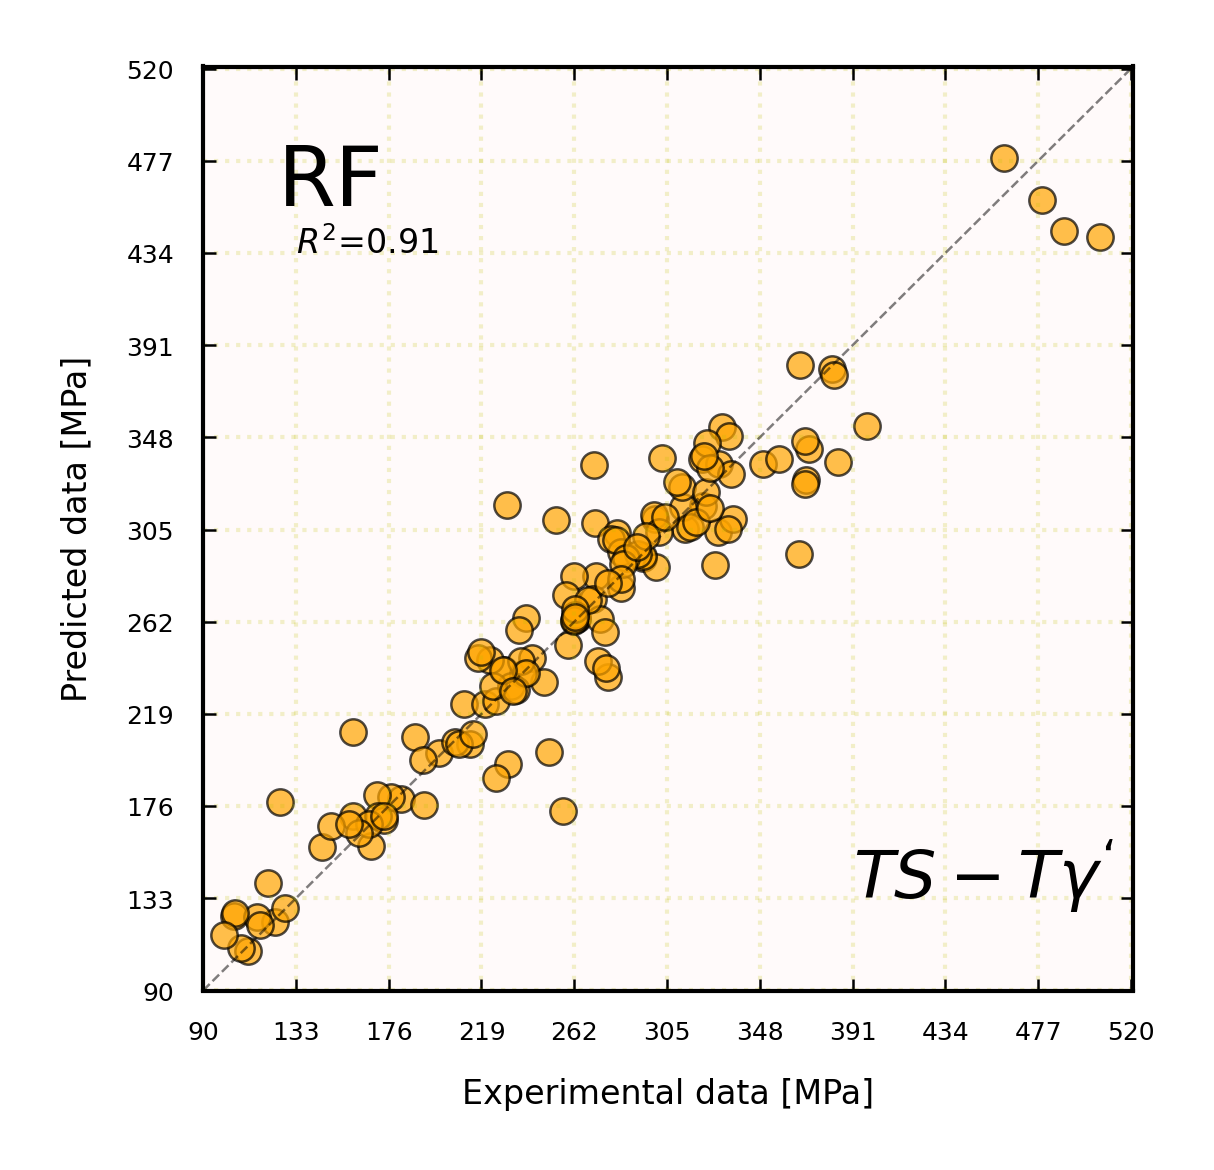

In [43]:
plt.rcParams['figure.figsize']=(2.0,2.0)
plt.rcParams['savefig.dpi'] = 600 #图片像素
plt.rcParams['figure.dpi'] = 600 #分辨率
ax = plt.axes()
ax.set_facecolor("snow")
ax.set(facecolor = "snow")#背景颜色设置
plt.grid()
plt.tick_params(grid_color='y',grid_alpha=0.2,
                        grid_linewidth=0.5,grid_linestyle=':')#网格背景划分
ax.spines['bottom'].set_linewidth('0.5')#设置边框线宽为2.0
ax.spines['bottom'].set_linestyle("-")
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_linewidth('0.5')#设置边框线宽为2.0
ax.spines['left'].set_linestyle("-")
ax.spines['left'].set_color('black')
ax.spines['top'].set_linewidth('0.5')#设置边框线宽为2.0
ax.spines['top'].set_linestyle("-")
ax.spines['top'].set_color('black')
ax.spines['right'].set_linewidth('0.5')#设置边框线宽为2.0
ax.spines['right'].set_linestyle("-")
ax.spines['right'].set_color('black')
#设置图框线粗细
new_ticks = list(np.arange(90,521,43))
plt.xticks(new_ticks,size=3)
plt.yticks(new_ticks,size=3)
plt.tick_params( which='major', direction='in', length=1.5,width=0.3, color='red', top=True,right=True)#设置边框刻度
plt.legend(title='RF',frameon=False)
plt.text(133, 434,'$R^2$=0.91',fontsize=4)# 在图中添加文字
plt.text(391, 133,'$TS-Tγ^‘$',fontsize=8)# 在图中添加文字
plt.plot([90,521],[90,521],'k--',linewidth = '0.3',alpha=0.5)
plt.scatter(test_labels7,predictions7,alpha=0.7,s=10,linewidths=0.3, c='orange',edgecolor='#000000')
plt.tick_params(axis='x',colors='black')
plt.tick_params(axis='y',colors='black')
plt.xlabel('Experimental data [MPa]',size=4)
plt.ylabel('Predicted data [MPa]',size=4)
plt.margins(x=0)
plt.margins(y=0)
plt.show()

In [45]:
data=pd.read_excel('weiguan的副本3.xlsx')
data=data.drop('合金序号', axis = 1)
data

,Ni,Cr,Co,Fe,Al,Ti,Nb,Mo,W,C,B,Zr
0,53.424,18.688,15.360,3.671,2.080,3.392,0.807,2.578,0.000,0.000,0,0
1,52.622,17.565,11.173,0.000,2.015,4.577,2.657,2.414,6.892,0.085,0,0
2,60.219,18.095,6.346,3.972,1.648,4.813,2.178,0.482,2.194,0.053,0,0


In [48]:
new_data_x_scaled=np.array(data)#获取影响因子
predicted_y1 = Model1.predict(new_data_x_scaled)
predicted_y2 = Model2.predict(new_data_x_scaled)
predicted_y3 = Model3.predict(new_data_x_scaled)
predicted_y4 = Model4.predict(new_data_x_scaled)
predicted_y5 = Model5.predict(new_data_x_scaled)
predicted_y6 = Model6.predict(new_data_x_scaled)
predicted_y7 = Model7.predict(new_data_x_scaled)
result_df = pd.DataFrame({'X': new_data_x_scaled.tolist(), '基体相体积分数': predicted_y1,
                             '强化相体积分数': predicted_y2,'液相温度': predicted_y3,'固相温度': predicted_y4,
                             '凝固区间': predicted_y5,'强化相溶解温度': predicted_y6,'加工窗口': predicted_y7,
                             })#将预测的真实值进行还原
result_df.to_excel('微观性能预测结果_5.xlsx', index=False)#保存到表格

In [ ]:
result_df = pd.DataFrame({'X': new_data_x_scaled.tolist(), '基体相体积分数': predicted_y1,
                             '强化相体积分数': predicted_y2,'液相温度': predicted_y3,'固相温度': predicted_y4,
                             '凝固区间': predicted_y5,'强化相溶解温度': predicted_y6,'加工窗口': predicted_y7,
                             })#将预测的真实值进行还原
result_df.to_excel('微观性能预测结果_5.xlsx', index=False)#保存到表格